# Imports

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import precision_recall_curve, roc_curve, roc_auc_score, confusion_matrix, classification_report

#Présentation du scénario

- Import des données
- Grâce aux indications des labels, on transforme les labels en booléens binaires : 0 si le paquet est légitime, 1 sinon
- On prépare les 4 dimensions du contexte de l'algorithme de MINDS

Nombre de paquets :  2087508
Nombre de colonnes manquantes :  12212
Nombre de paquets après nettoyage :  2077287 



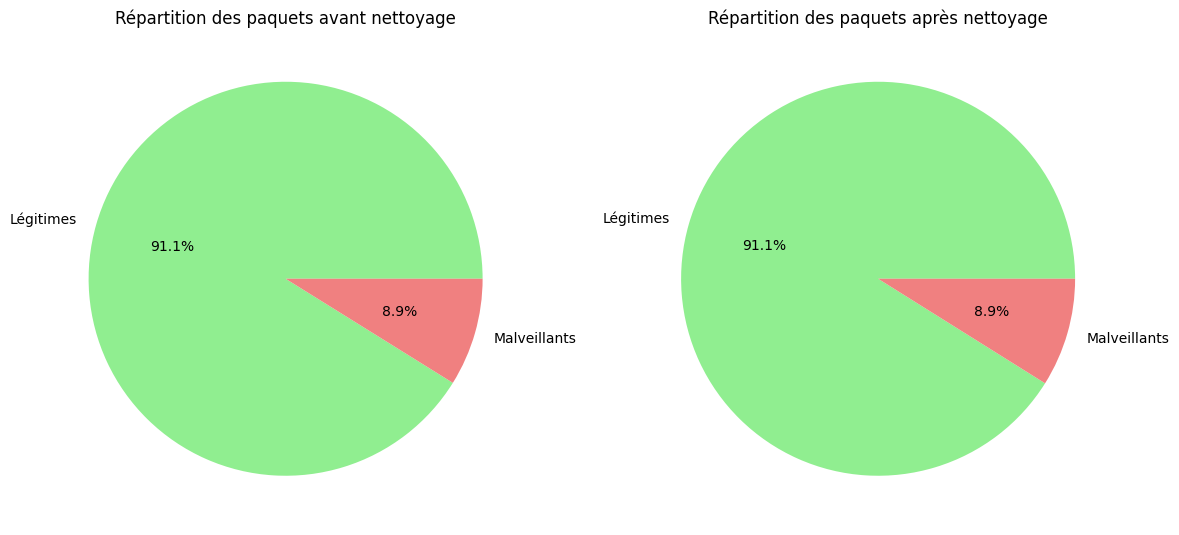

In [ ]:
file_path = r"/content/capture20110817.binetflow.txt"
data = pd.read_csv(file_path, header=0, low_memory=False)
print("Nombre de paquets : ", len(data))

# On fait des booléens binaires au lieu de garder une chaine de caractères
data['Label'] = data['Label'].apply(lambda x: 0 if 'Normal' in x or 'Background' in x else 1)

before = data['Label'].value_counts()
print("Nombre de colonnes manquantes : ", data[['SrcAddr', 'Dport', 'Sport', 'DstAddr']].isna().sum().sum())

# Nettoyage : suppression des lignes où l'une des dimensions n'est pas renseignée
data = data.dropna(subset=['SrcAddr', 'Dport', 'Sport','DstAddr'])
after = data['Label'].value_counts()
print("Nombre de paquets après nettoyage : ", len(data), "\n")

# Changement sur la colonne date pour définir un début
data['StartTime'] = pd.to_datetime(data['StartTime'], errors='coerce')
start_time = data['StartTime'].min()
data['StartTime'] = (data['StartTime'] - start_time).dt.total_seconds()

# Présentation du scénario
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].pie(
    before,
    labels=['Légitimes', 'Malveillants'],
    autopct='%1.1f%%',
    colors=['lightgreen', 'lightcoral']
)
axes[0].set_title("Répartition des paquets avant nettoyage")

axes[1].pie(
    after,
    labels=['Légitimes', 'Malveillants'],
    autopct='%1.1f%%',
    colors=['lightgreen', 'lightcoral']
)
axes[1].set_title("Répartition des paquets après nettoyage")

plt.tight_layout()
plt.show()

In [ ]:
# Fenêtrage
window_duration = 300
data['Window'] = (data['StartTime'] // window_duration).astype(int)

# Les 4 dimensions de MINDS
data['src_count'] = data.groupby('SrcAddr')['SrcAddr'].transform('count')
data['dst_count'] = data.groupby('DstAddr')['DstAddr'].transform('count')
data['src_dst_port_count'] = data.groupby(['SrcAddr', 'Dport'])['Dport'].transform('count')
data['src_port_dst_count'] = data.groupby(['Sport', 'DstAddr'])['DstAddr'].transform('count')

features = ['src_count', 'dst_count', 'src_dst_port_count', 'src_port_dst_count']
data[features] = np.log1p(data[features])

#Entrainement

On doit sélectionner le flux légitime dans un intervalle de temps donné pour entrainer l'algorithme. Le but est que l'algorithme apprenne le comportement "normal" du trafic en étudiant du flux légitime.

In [ ]:
t = 40

# Séparer le paquet d'entraînement (légitime avant t minutes)
train_data = data[
    (data['Label'] == 0) &
    (data['StartTime']  <= t * 60)
].copy()

for feature in features:
    window_means = train_data.groupby('Window')[feature].transform('mean')
    train_data[feature] = window_means
means = train_data[features].mean()
stds = train_data[features].std()

# Le paquet test contient tous les autres paquets (après t minutes)
test_data = data[(data['StartTime'] > t * 60)].copy()
for feature in features:
    window_means = test_data.groupby('Window')[feature].transform('mean')
    test_data[feature] = window_means
test_data['minds_score'] = np.linalg.norm((test_data[features] - means) / stds, axis=1)
test_data['Window_Label'] = test_data.groupby('Window')['Label'].transform('max')

print("Taille de l'ensemble d'entrainement : ", len(train_data))
print("Nombre de paquets malveillant dans l'ensemble d'entrainement : ", len(train_data[train_data['Label'] == 1]))

Taille de l'ensemble d'entrainement :  78973
Nombre de paquets malveillant dans l'ensemble d'entrainement :  0


# Détermination du seuil

Le seuil doit être fixé minutieusement car de lui dépend la précision de notre algorithme. Nous utilisons une courbe ROC pour le déterminer. Elle montre l'équilibre entre les taux de vrais positifs et de vrais négatifs.

À partir de cette courbe, il existe plusieurs méthodes pour déterminer le seuil optimal :
- Méthode de la distance minimale : Elle minimise la distance euclidienne au point parfait (0, 1) sur la courbe ROC, cherchant un compromis équilibré entre les vrais positifs et les faux positifs.

- Méthode de Youden : Elle maximise la statistique J = TPR - FPR, visant à optimiser la sensibilité tout en minimisant les faux positifs, idéal pour un compromis entre détection et fausses alertes.

Nous pouvons également calculer le score ROC-AUC qui mesure la capacité d'un modèle à distinguer les classes positives et négatives : il s'agit de l'aire sous la courbe ROC. Un score de 1 signifie une parfaite distinction entre les classes, tandis qu'un score de 0.5 indique que le modèle ne fait pas mieux que le hasard.

Point parfait : 12.61
Statistique de Youden : 14.25
Score ROC-AUC : 0.85



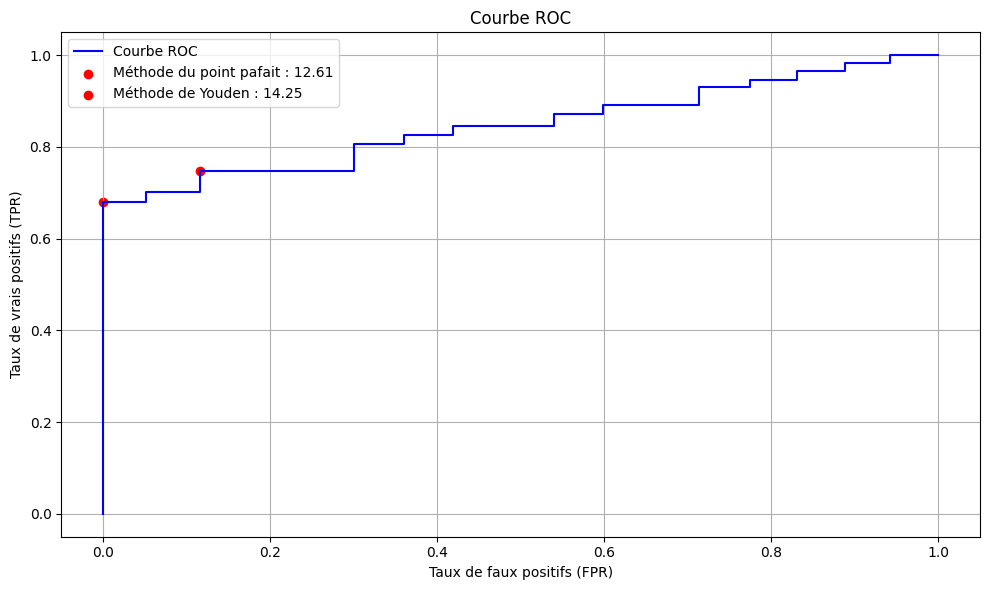

In [ ]:
# Calcul de la courbe ROC
f1 = test_data['Window_Label']
f2 = test_data['minds_score']
fpr, tpr, thresholds = roc_curve(f1, f2)
roc_auc = roc_auc_score(f1, f2)

# Calcul de la distance euclidienne au point parfait (0,1)
distances = np.sqrt((fpr - 0)**2 + (tpr - 1)**2)
threshold_idx1 = np.argmin(distances)
threshold1 = thresholds[threshold_idx1]

# Calcul de la statistique de Youden
youden_j = tpr - fpr
threshold_idx2 = np.argmax(youden_j)
threshold2 = thresholds[threshold_idx2]

print(f"Point parfait : {threshold1:.2f}")
print(f"Statistique de Youden : {threshold2:.2f}")
print(f"Score ROC-AUC : {roc_auc:.2f}\n")

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', label="Courbe ROC")
plt.scatter(fpr[threshold_idx1], tpr[threshold_idx1], color='red', label=f"Méthode du point pafait : {threshold1:.2f}")
plt.scatter(fpr[threshold_idx2], tpr[threshold_idx2], color='red', label=f"Méthode de Youden : {threshold2:.2f}")
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.legend()
plt.title("Courbe ROC")
plt.grid(True)
plt.tight_layout()
plt.show()

# Test

Une fois le seuil choisi, on peut donc discriminer les flux selon leur score d'anomalie. Nous avons choisi d'utiliser le seuil obtenu grâce à la méthode de Youden, car les résultats sont meilleurs pour ce scénario.

----------------- Données d'entrainement et de test -----------------

Taille de la fenêtre temporel :  300 secondes
Durée d'entrainement :  40  min
Seuil : 14.25
Nombre de flux testés :  1998314 

--------------------- Rapport de classification ---------------------

              precision    recall  f1-score   support

           0       0.98      0.54      0.70   1813327
           1       0.17      0.91      0.28    184987

    accuracy                           0.57   1998314
   macro avg       0.58      0.72      0.49   1998314
weighted avg       0.91      0.57      0.66   1998314
 

------------------------ Matrice de confusion -----------------------



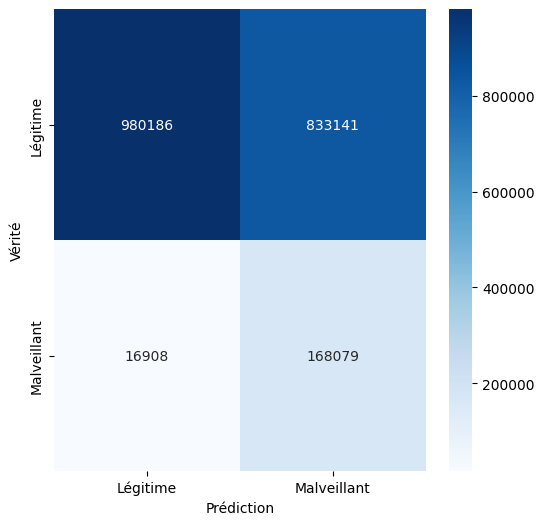

In [ ]:
# Changer l'entier après threshold pour changer de seuil
test_data['Predicted_Label'] = (test_data['minds_score'] > threshold2).astype(int)

N = len(test_data)
y_true = test_data['Label']
y_pred = test_data['Predicted_Label']
cm = confusion_matrix(y_true, y_pred)
cr = classification_report(y_true, y_pred)

print("----------------- Données d'entrainement et de test -----------------\n")
print("Taille de la fenêtre temporel : ", window_duration, "secondes")
print("Durée d'entrainement : ", t, " min")
print(f"Seuil : {threshold2:.2f}")
print("Nombre de flux testés : ",N,"\n")
print("--------------------- Rapport de classification ---------------------\n")
print(cr,"\n")
print("------------------------ Matrice de confusion -----------------------\n")
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Légitime", "Malveillant"], yticklabels=["Légitime", "Malveillant"])
plt.xlabel('Prédiction')
plt.ylabel('Vérité')
plt.show()

# Analyse des faux positifs

Nous remarquons un grand nombre de faux positifs, ce qui est assez problématique pour de l'adminisration réseau. Cette partie va tenter d'analyser quel type de flux est faussement détecté.

In [ ]:
fp = test_data[(test_data['Label'] == 0) & (test_data['Predicted_Label'] == 1)]
vp = test_data[(test_data['Label'] == 0) & (test_data['Predicted_Label'] == 0)]



```
# Ce texte est au format code
```

### Analyse des IP Source

In [ ]:
print("Faux positifs\n")
print(fp['SrcAddr'].value_counts(),"\n")
print("Vrais positifs\n")
print(vp['SrcAddr'].value_counts(),"\n")

Faux positifs

SrcAddr
147.32.84.138     244110
147.32.84.59      133341
147.32.84.229      29069
147.32.86.165      19899
147.32.85.25       19145
                   ...  
87.16.100.58           1
46.237.74.175          1
84.226.79.129          1
114.47.192.160         1
176.14.254.34          1
Name: count, Length: 186975, dtype: int64 

Vrais positifs

SrcAddr
147.32.84.138     162905
147.32.84.59      142808
147.32.84.229      38662
147.32.86.165      29912
147.32.85.25       21579
                   ...  
89.191.112.154         1
86.202.166.184         1
71.17.43.189           1
193.107.137.89         1
85.176.70.183          1
Name: count, Length: 190791, dtype: int64 



### Analyse des IP Destination

In [ ]:
print("Faux positifs\n")
print(fp['DstAddr'].value_counts(),"\n")
print("Vrais positifs\n")
print(vp['DstAddr'].value_counts(),"\n")

Faux positifs

DstAddr
147.32.80.9       414252
147.32.86.165     145902
147.32.84.229     106891
147.32.80.13        6180
89.221.216.24       5544
                   ...  
193.10.213.226         1
85.92.31.91            1
115.165.223.81         1
92.62.240.29           1
91.218.83.95           1
Name: count, Length: 50221, dtype: int64 

Vrais positifs

DstAddr
147.32.80.9        358922
147.32.86.165      148135
147.32.84.229      125053
147.32.80.13         9702
89.221.216.24        6175
                    ...  
93.116.228.18           1
109.106.229.53          1
99.230.126.106          1
193.248.114.206         1
79.138.27.26            1
Name: count, Length: 58168, dtype: int64 



# Analyse des Ports Source avec même IP Destination

In [ ]:
print("Faux positifs\n")
print(fp[['Sport', 'DstAddr']].value_counts(),"\n")
print("Vrais positifs\n")
print(vp[['Sport', 'DstAddr']].value_counts(),"\n")

Faux positifs

Sport   DstAddr      
0x0303  147.32.80.9      835
        147.32.84.94     689
        147.32.84.229    527
0x0103  147.32.84.229    351
0x0303  147.32.86.165    298
                        ... 
0x0003  147.32.85.26       1
        147.32.85.34       1
        147.32.85.84       1
9993    81.0.235.21        1
9994    147.32.86.165      1
Name: count, Length: 347159, dtype: int64 

Vrais positifs

Sport   DstAddr       
0x0303  147.32.80.9       721
        147.32.84.229     673
35248   188.75.133.98     600
6881    147.32.84.118     454
0x0303  147.32.86.165     404
                         ... 
35921   147.32.192.127      1
35920   209.85.148.99       1
        147.32.86.165       1
        147.32.84.229       1
35922   209.85.148.99       1
Name: count, Length: 382989, dtype: int64 



# Analyse des Port Destination avec même IP Source

In [ ]:
print("Faux positifs\n")
print(fp[['Dport', 'SrcAddr']].value_counts(),"\n")
print("Vrais positifs\n")
print(vp[['Dport', 'SrcAddr']].value_counts(),"\n")

Faux positifs

Dport  SrcAddr      
53     147.32.84.138    240877
       147.32.84.59      72660
80     147.32.84.59      35803
53     147.32.85.25      19145
       147.32.85.34      11029
                         ...  
12114  86.60.170.59          1
       86.60.175.126         1
       86.60.46.33           1
       86.60.54.225          1
       86.59.34.146          1
Name: count, Length: 251917, dtype: int64 

Vrais positifs

Dport   SrcAddr       
53      147.32.84.138     162807
        147.32.84.59       73844
80      147.32.84.59       39599
53      147.32.85.25       21579
        147.32.85.34       12802
                           ...  
9970    147.32.86.165          1
9968    147.32.86.208          1
9962    147.32.86.165          1
0x0001  178.178.35.246         1
        117.242.80.168         1
Name: count, Length: 265416, dtype: int64 



On remarque un très grand nombre de faux positifs en provenance de 147.32.84.441 à destination du port 53.

In [ ]:
analyse = test_data[(test_data['SrcAddr'] == '147.32.84.138') & (test_data['Dport'] == '53')]

print(analyse['Proto'].value_counts(), "\n")

fp2 = analyse[(analyse['Label'] == 0) & (analyse['Predicted_Label'] == 1)]
vp2 = analyse[(analyse['Label'] == 0) & (analyse['Predicted_Label'] == 0)]

print("Nombre du paquet malveillant :", len(analyse[(analyse['Label'] == 1)]), "\n")

print(fp2.head())
print(vp2.head())

Proto
udp    403684
Name: count, dtype: int64 

Nombre du paquet malveillant : 0 

          StartTime       Dur Proto        SrcAddr  Sport    Dir      DstAddr  \
255571  4440.544259  0.000197   udp  147.32.84.138  43752    <->  147.32.80.9   
255572  4440.544324  0.000252   udp  147.32.84.138  34431    <->  147.32.80.9   
255573  4440.551692  0.000175   udp  147.32.84.138  33779    <->  147.32.80.9   
255574  4440.551706  0.000174   udp  147.32.84.138  50294    <->  147.32.80.9   
255575  4440.559616  0.000377   udp  147.32.84.138  60864    <->  147.32.80.9   

       Dport State  sTos  ...  SrcBytes  Label  Window  src_count  dst_count  \
255571    53   CON   0.0  ...        81      0      37   8.232784  11.090816   
255572    53   CON   0.0  ...        81      0      37   8.232784  11.090816   
255573    53   CON   0.0  ...        81      0      37   8.232784  11.090816   
255574    53   CON   0.0  ...        81      0      37   8.232784  11.090816   
255575    53   CON   0.0  ... 

À ce stade, on peut simplement supposer qu'il y a eu un grand nombre de requêtes de 147.32.84.138 vers 147.32.80.9 (à priori DNS car port 53), qui a conduit à une augmentation significative des caractéristiques de MINDS. Cela trompe notre détecteur.

# Conclusion

On peut statuer que, dès lors que le traffic est important et qu'il y a un nombre important de requêtes entre deux entités, les métriques augmentent et trompent notre détecteur. Pour éviter cela, on pourrait prendre en compte d'autres paramètres.

In [ ]:
print(test_data['StartTime'].max())

20244.430554
